# Diagnostic Figures for CSDID Analysis

Replicates Figures 1–5 from the CSDID notes.

- **Fig 1**: Control pool over time, before activity filter (71 treatment events, from `agreement_ged`)
- **Fig 2**: Pre-agreement violence by treated conflict; threshold at ln(13)≈2.56
- **Fig 3**: Active control pool after activity filter (66 treatment events)
- **Fig 4**: Side-by-side pre-treatment violence — raw vs filtered
- **Fig 5**: Side-by-side violence trajectories — raw vs filtered

Input: `data/output/conflict_level/conflict_panel_unified.csv` (monthly panel, 201 conflicts).

**Key alignment with `first_agreement_csdid.do`:**
- Treatment identification uses `agreement_ged` (active-violence months only, 71 conflicts).
- Activity filter: `deaths_prev2q` NaN → 0 before computing window, matching Stata's
  `replace _conflict_prev2 = 0 if _conflict_prev2 == .` (Section 5). Gives 66 treated.
- `ever_agreement` and descriptive tables are based on `agreement_ged`.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import os
import sys



utils_path = os.path.abspath(
    os.path.join(os.getcwd(), '..', '2_data_analysis', 'utils')
)
sys.path.append(utils_path)
import plot_style


C_AGR   = '#C0392B'   # red  — treated / agreement
C_NOAGR = '#2C6E8A'   # blue — control / no agreement
THRESHOLD = 12        # deaths in prior 2 quarters (activity threshold)

BASE   = Path('../../')
OUTDIR = Path('results/descriptives')
OUTDIR.mkdir(parents=True, exist_ok=True)
print('Output dir:', OUTDIR.resolve())

Output dir: /Users/luciasauer/Library/CloudStorage/GoogleDrive-lucia.sauer@bse.eu/Mi unidad/EconAI/1_agreements_violence/agreements_violence/src/4_csdid/results/descriptives


## 1. Load and parse monthly panel

In [8]:
df = pd.read_csv(
    BASE / 'data/output/conflict_level/conflict_panel.csv',
    low_memory=False
)
print(f'Loaded: {df.shape[0]:,} rows, {df["conflict_id"].nunique()} conflicts')

# Parse year-month
df['year']    = df['year_mo'].str[:4].astype(int)
df['month']   = df['year_mo'].str[5:7].astype(int)
df['quarter'] = (df['month'] - 1) // 3 + 1
df['yq_int']  = (df['year'] - 1989) * 4 + df['quarter'] - 1   # 0-indexed: 0 = 1989Q1

# Parse start/end dates to yq_int
def date_to_yq(s):
    yr  = s.str[:4].astype(float)
    mo  = s.str[5:7].astype(float)
    qtr = (mo - 1) // 3 + 1
    return ((yr - 1989) * 4 + qtr - 1).astype(int)

df['start_yq'] = date_to_yq(df['start_date'])
df['end_yq']   = date_to_yq(df['end_date'])

# Sort for cumulative sums
df = df.sort_values(['conflict_id', 'year_mo_numeric']).reset_index(drop=True)

print('yq_int range:', df['yq_int'].min(), '–', df['yq_int'].max(),
      ' (', 1989 + df['yq_int'].min()//4, 'Q', df['yq_int'].min()%4+1,
      '–', 1989 + df['yq_int'].max()//4, 'Q', df['yq_int'].max()%4+1, ')')

Loaded: 86,832 rows, 201 conflicts
yq_int range: 0 – 143  ( 1989 Q 1 – 2024 Q 4 )


## 2. Identify first agreement and compute 7-month window deaths

In [9]:
# First-agreement flag at monthly level
df['cum_agree']        = df.groupby('conflict_id')['agreement_ged'].cumsum()
df['first_agree_flag'] = ((df['agreement_ged'] == 1) & (df['cum_agree'] == 1)).astype(int)

# Per-conflict first_agreement_quarter (as yq_int) and agreement month number
first_agree_info = (
    df[df['first_agree_flag'] == 1]
    .groupby('conflict_id')[['yq_int', 'year_mo_numeric']]
    .first()
    .rename(columns={
        'yq_int':          'first_agreement_quarter',
        'year_mo_numeric': 'agree_month_num',
    })
)
print(f'Conflicts with a first agreement: {len(first_agree_info)}')  # expect 71

# Country labels (used by Figures 2–3)
conflict_labels = (
    df[['conflict_id', 'country']]
    .drop_duplicates('conflict_id')
    .set_index('conflict_id')['country']
)

# Merge first_agreement_quarter back so the quarterly collapse can carry it
df = df.merge(first_agree_info[['first_agreement_quarter']], on='conflict_id', how='left')

Conflicts with a first agreement: 71


## 3. Quarterly collapse

In [10]:
df_q = (
    df.groupby(['conflict_id', 'yq_int'])
    .agg(
        best                    = ('best',                    'sum'),
        n_events                = ('n_events',                'sum'),
        first_agreement         = ('first_agree_flag',        'max'),
        start_yq                = ('start_yq',                'first'),
        end_yq                  = ('end_yq',                  'first'),
        country                 = ('country',                 'first'),
        region                  = ('region',                  'first'),
        first_agreement_quarter = ('first_agreement_quarter', 'first'),
    )
    .reset_index()
)
df_q['ln_deaths'] = np.log(df_q['best'] + 1)

# Deaths in prior 2 quarters (used for both the activity filter and control selection)
df_q = df_q.sort_values(['conflict_id', 'yq_int'])
df_q['lag1_best']     = df_q.groupby('conflict_id')['best'].shift(1)
df_q['lag2_best']     = df_q.groupby('conflict_id')['best'].shift(2)
df_q['deaths_prev2q'] = df_q['lag1_best'] + df_q['lag2_best']

# ── Activity filter at QUARTERLY level ────────────────────────────────────────
# Mirrors first_agreement_csdid.do Section 5:
#   replace _conflict_prev2 = 0 if _conflict_prev2 == .
#   → agreement in first 2 quarters of spell: pre-onset deaths are 0 by definition.
#   keep treated if deaths_prev2q_filled + best_at_treat_quarter >= THRESHOLD
treat_q = df_q[df_q['first_agreement'] == 1][['conflict_id', 'deaths_prev2q', 'best']].copy()
treat_q['deaths_prev2q_filled'] = treat_q['deaths_prev2q'].fillna(0)
treat_q['window_deaths_q']      = treat_q['deaths_prev2q_filled'] + treat_q['best']
treat_q['active']               = treat_q['window_deaths_q'] >= THRESHOLD
treat_q = treat_q.set_index('conflict_id')

# Attach to first_agree_info for use in Figure 2 and onwards
first_agree_info = first_agree_info.join(treat_q[['window_deaths_q', 'active']])
first_agree_info['active'] = first_agree_info['active'].fillna(False)

active_ids = set(first_agree_info[first_agree_info['active']].index)
n_active   = len(active_ids)
n_inactive = len(first_agree_info) - n_active

print(f'Active (kept as treated):    {n_active}')   # expect 66
print(f'Low-activity (reclassified): {n_inactive}')  # expect 5

print('\nExcluded conflicts (window_deaths_q < 12):')
excl = first_agree_info[~first_agree_info['active']].copy()
excl['country'] = excl.index.map(conflict_labels)
print(excl[['country', 'window_deaths_q']].to_string())

# Reclassify inactive treated conflicts as never-treated
df_q['first_agreement_quarter_f'] = df_q['first_agreement_quarter'].where(
    df_q['conflict_id'].isin(active_ids), other=np.nan
)
df_q['first_agreement_f'] = (
    df_q['first_agreement'].astype(bool) &
    df_q['conflict_id'].isin(active_ids)
).astype(int)

print(f'\nQuarterly panel shape: {df_q.shape}')
print(f'Treatment events (pre-filter):  {df_q["first_agreement"].sum()}')
print(f'Treatment events (post-filter): {df_q["first_agreement_f"].sum()}')

Active (kept as treated):    66
Low-activity (reclassified): 5

Excluded conflicts (window_deaths_q < 12):
                    country  window_deaths_q
conflict_id                                 
287                 Burundi              9.0
315          United Kingdom              8.0
342                   Spain              3.0
372                    Mali              7.0
387                  Angola              3.0

Quarterly panel shape: (28944, 16)
Treatment events (pre-filter):  71
Treatment events (post-filter): 66


## 4. Helper: yq_int → float year (for x-axis)

In [11]:
def yq_to_float(yq_int):
    """Convert 0-indexed quarter int to float year (1989.0 = Q1 1989)."""
    year = 1989 + np.asarray(yq_int, dtype=float) // 4
    q    = np.asarray(yq_int, dtype=float) % 4
    return year + q * 0.25

def yq_to_label(yq_int):
    """Human-readable label like '1992Q3'."""
    year = 1989 + int(yq_int) // 4
    q    = int(yq_int) % 4 + 1
    return f'{year}Q{q}'

# Test
print('yq_int 0  →', yq_to_label(0),  yq_to_float(0))
print('yq_int 13 →', yq_to_label(13), yq_to_float(13))
print('yq_int 132→', yq_to_label(132), yq_to_float(132))

yq_int 0  → 1989Q1 1989.0
yq_int 13 → 1992Q2 1992.25
yq_int 132→ 2022Q1 2022.0


## Figure 1 — Control pool before activity filter

Treatment events: 71


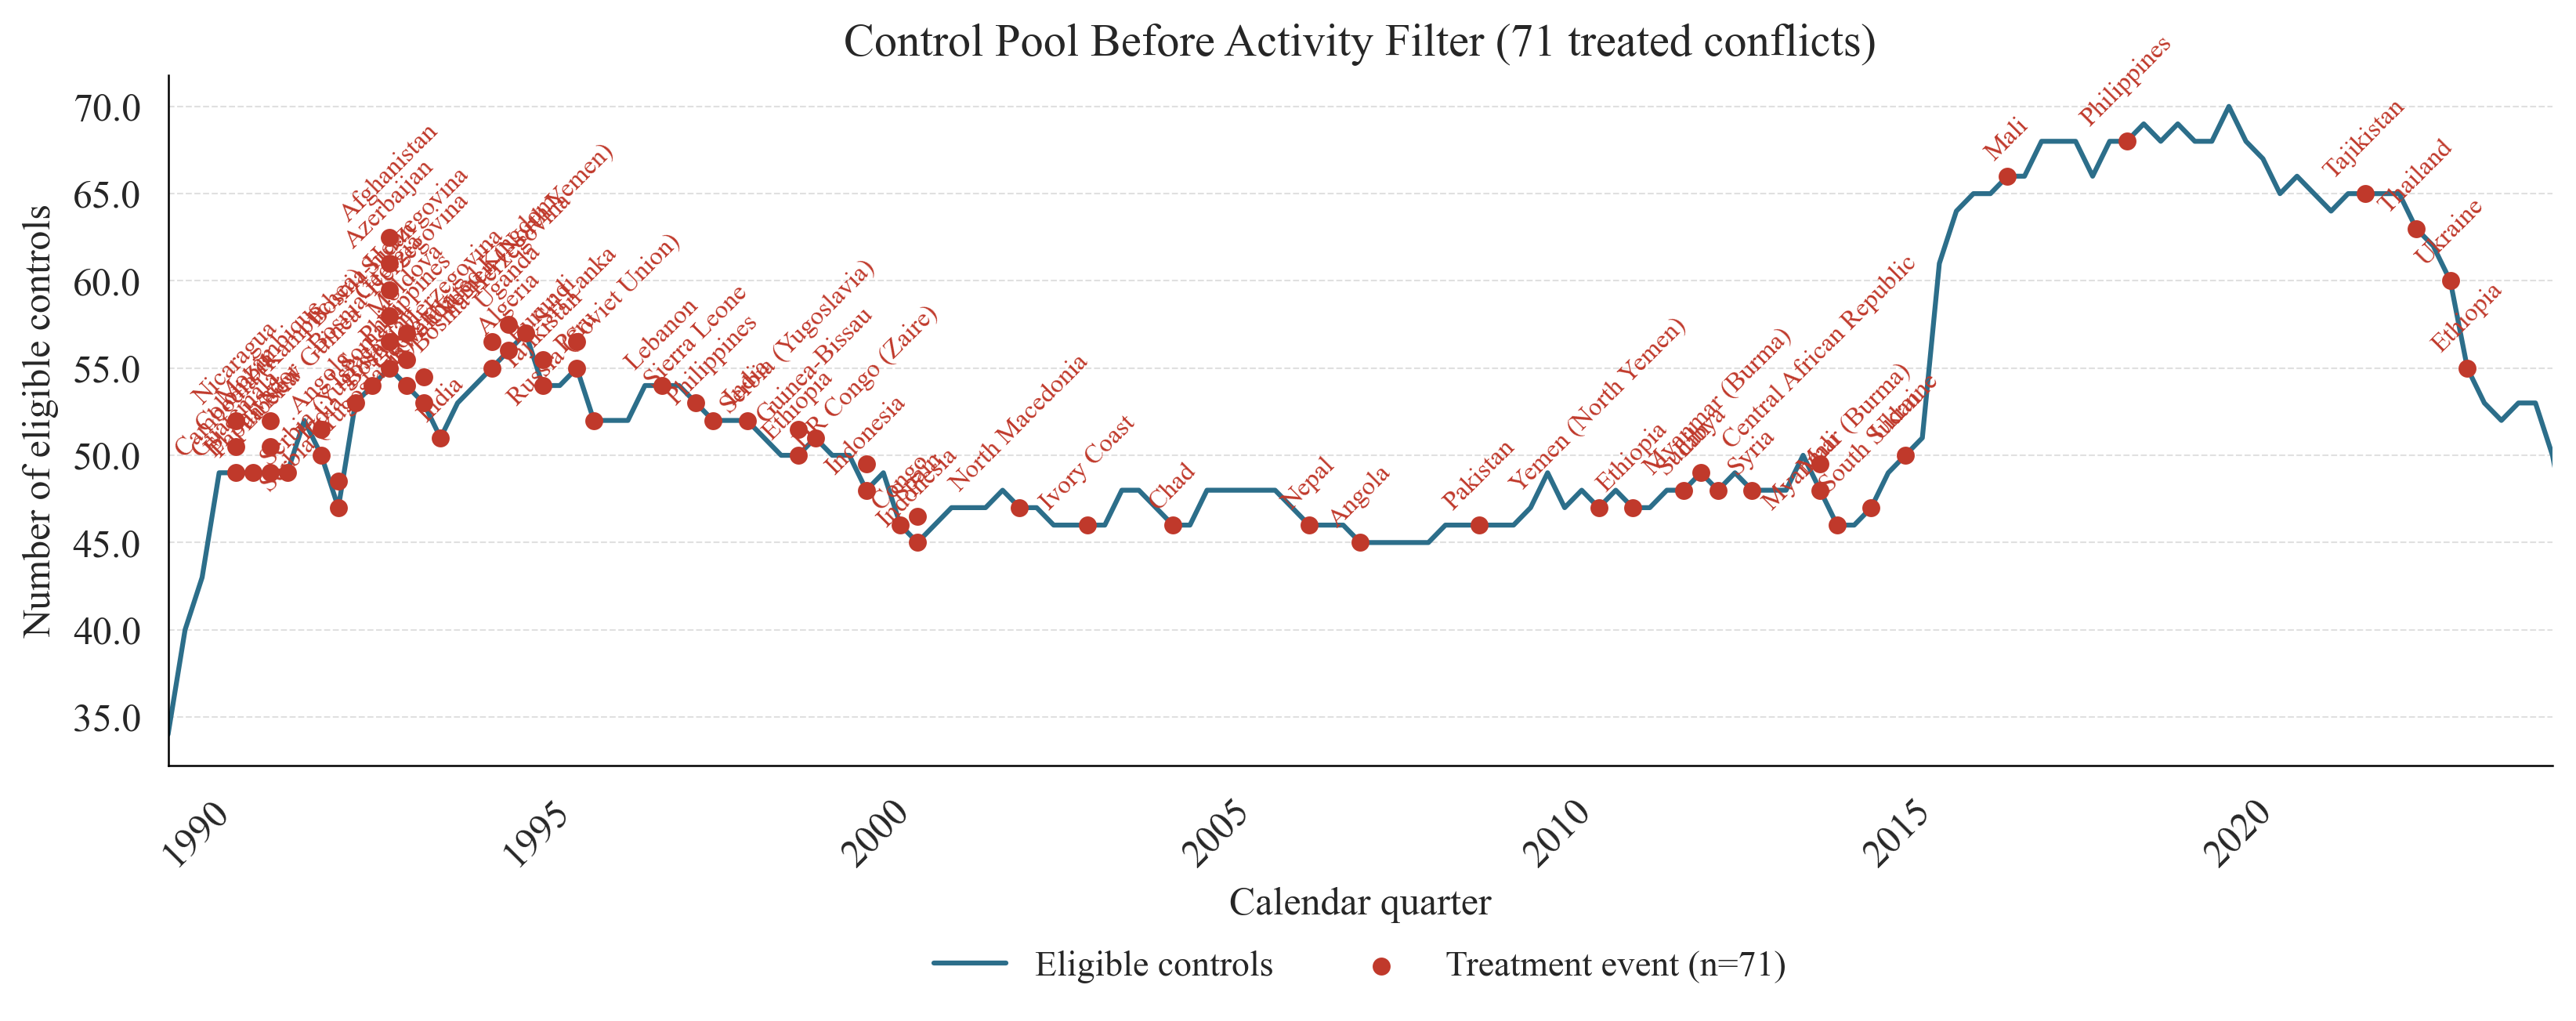

Saved: results/descriptives/fig1_control_pool_pre.png


In [12]:
# Eligible control at (conflict, yq): alive AND (never-treated OR not-yet-treated)
df_q['elig_pre'] = (
    (df_q['start_yq'] <= df_q['yq_int']) &
    (df_q['yq_int']   <= df_q['end_yq']) &
    (
        df_q['first_agreement_quarter'].isna() |
        (df_q['yq_int'] < df_q['first_agreement_quarter'])
    )
).astype(int)

n_ctrl_pre = df_q.groupby('yq_int')['elig_pre'].sum()

# Treatment events (71 red dots)
treat_events = df_q[df_q['first_agreement'] == 1][['yq_int', 'country']].copy()
treat_events['y_base'] = treat_events['yq_int'].map(lambda q: n_ctrl_pre.get(q, 0))
treat_events['x']      = yq_to_float(treat_events['yq_int'].values)
treat_events = treat_events.sort_values('yq_int').reset_index(drop=True)
treat_events['rank_q'] = treat_events.groupby('yq_int').cumcount()
# Stack dots vertically in data units (1.5 per rank so they don't overlap)
treat_events['y_dot']  = treat_events['y_base'] + treat_events['rank_q'] * 1.5

print(f'Treatment events: {len(treat_events)}')

x_line = yq_to_float(n_ctrl_pre.index.values)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(x_line, n_ctrl_pre.values, color=C_NOAGR, lw=1.5, label='Eligible controls')
ax.scatter(treat_events['x'], treat_events['y_dot'],
           color=C_AGR, s=22, zorder=5, label=f'Treatment event (n={len(treat_events)})')
for _, row in treat_events.iterrows():
    ax.annotate(
        row['country'], (row['x'], row['y_dot']),
        textcoords="offset points", xytext=(0, 5),
        ha='center', fontsize=8, color=C_AGR, rotation=45
    )

ax.set_xlabel('Calendar quarter', fontsize=12)
ax.set_ylabel('Number of eligible controls', fontsize=12)
ax.set_title(
    f'Control Pool Before Activity Filter ({len(treat_events)} treated conflicts)',
    fontsize=14
)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22),
          frameon=False, fontsize=11, ncol=2)
ax.set_xlim(1989, 2024)
ticks = list(range(1990, 2025, 5))
ax.set_xticks(ticks)
ax.set_xticklabels([str(y) for y in ticks], rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(ax.get_yticks(), fontsize=12)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.grid(False, axis='x')
plt.tight_layout()
plt.savefig(OUTDIR / 'fig1_control_pool_pre.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', OUTDIR / 'fig1_control_pool_pre.png')

## Figure 2 — Pre-agreement violence by treated conflict

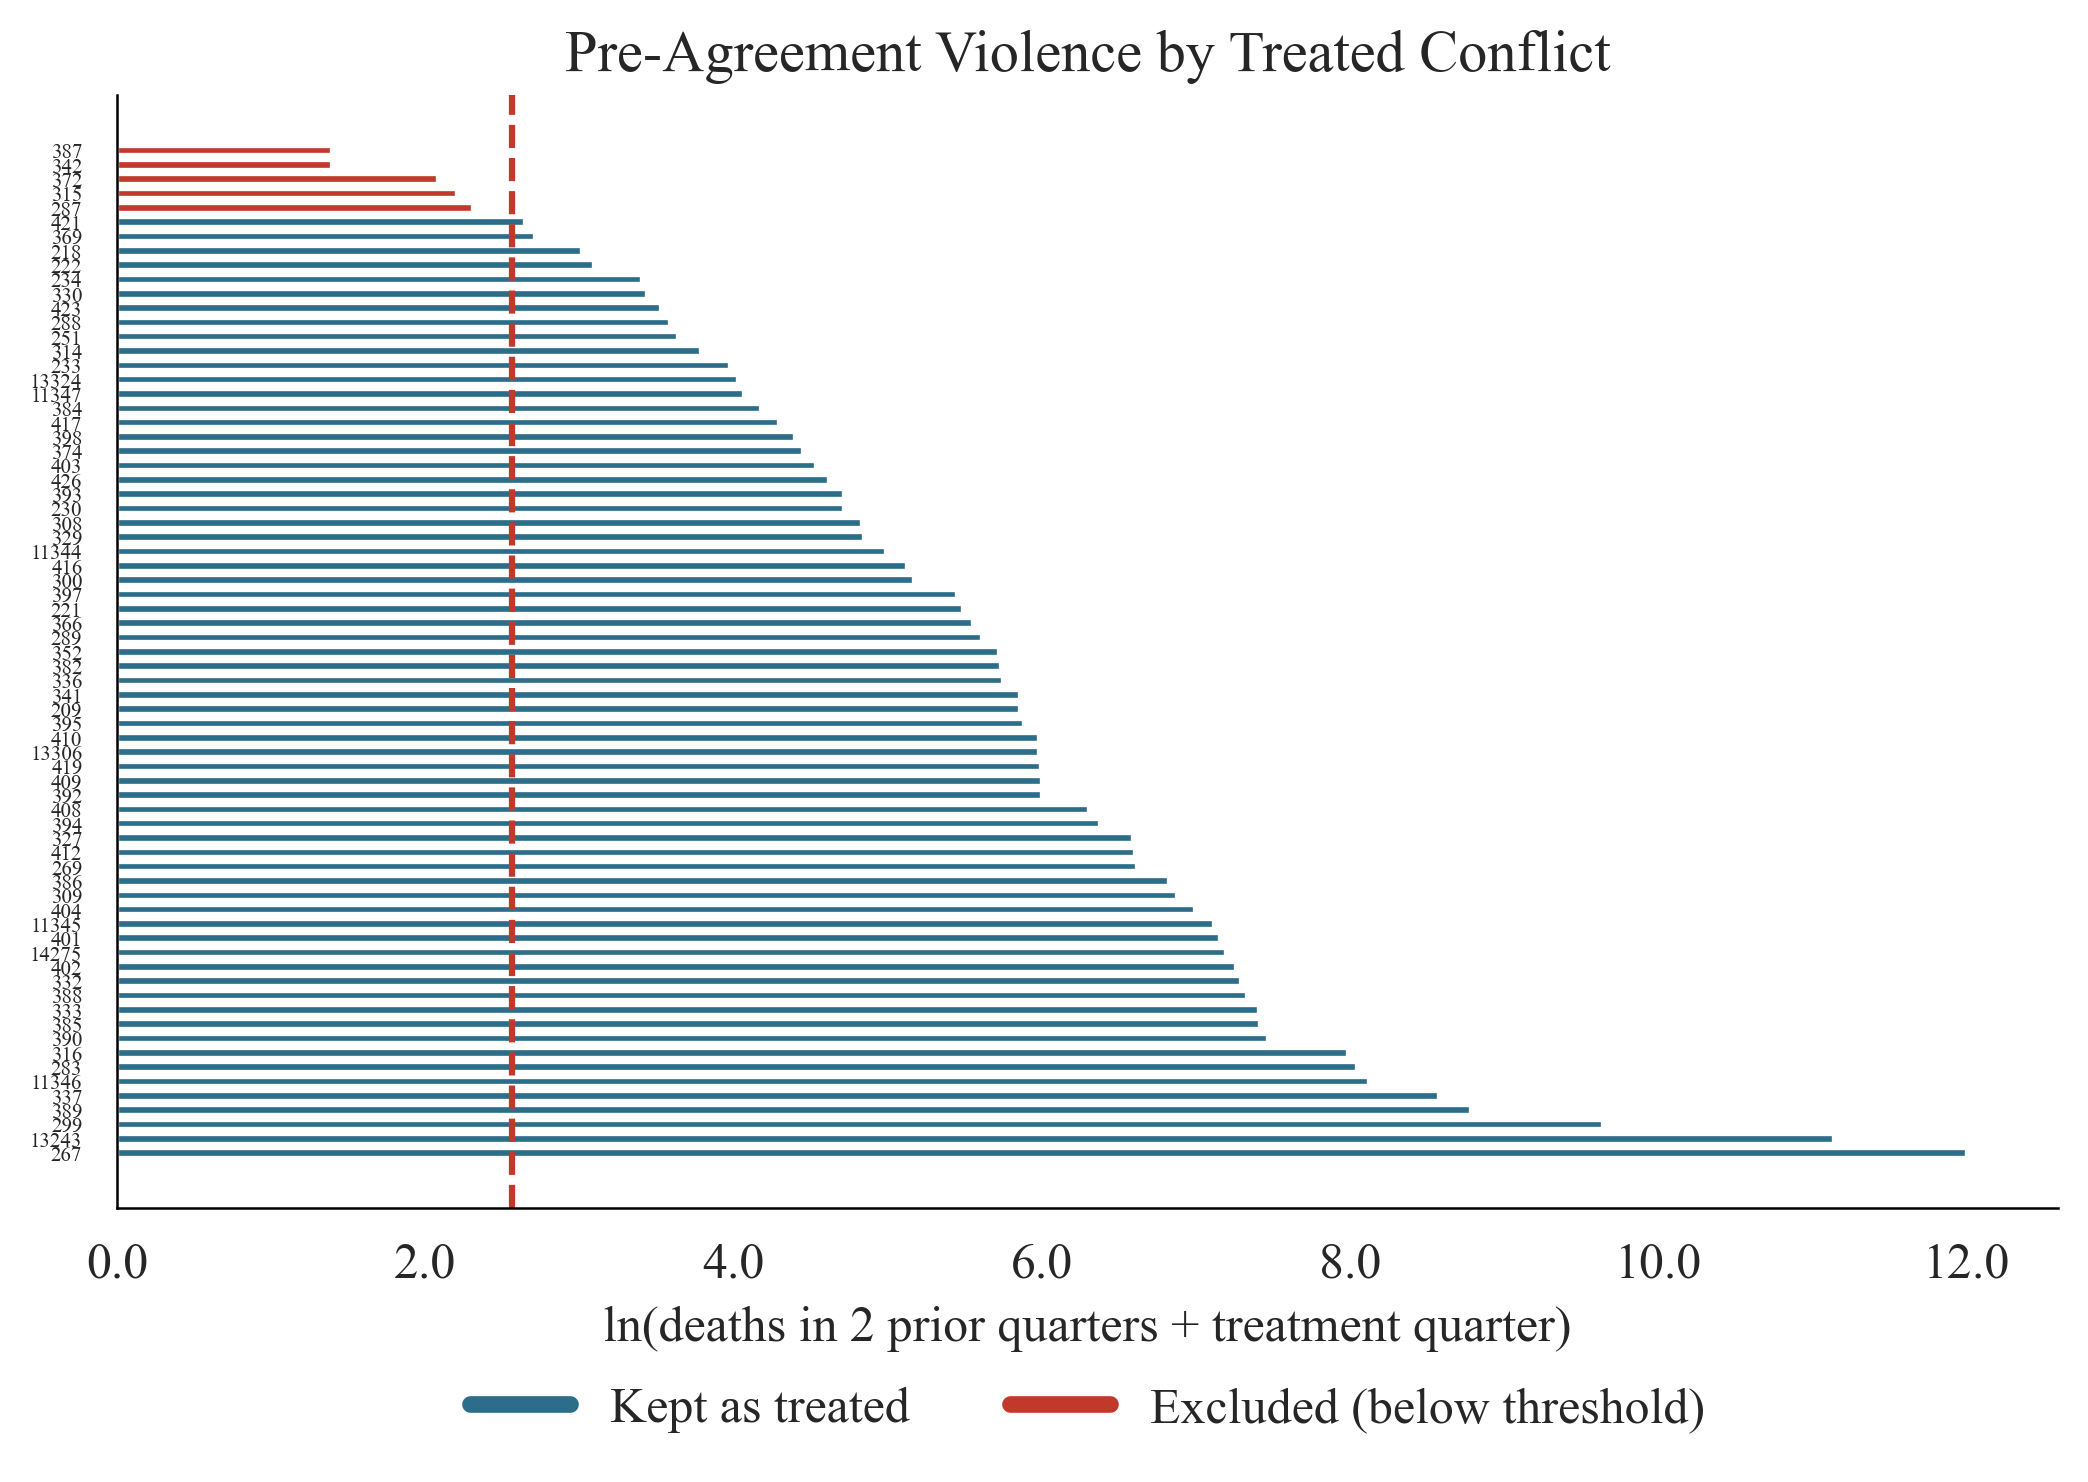

Saved | kept=66, excluded=5


In [13]:
fig2 = first_agree_info.copy().reset_index()
fig2['ln_window'] = np.log(fig2['window_deaths_q'] + 1)
# Sort: excluded (red) first, then kept (blue); ascending by value within each group
fig2 = fig2.sort_values(['active', 'window_deaths_q'], ascending=[False, False]).reset_index(drop=True)

ln_threshold = np.log(THRESHOLD + 1) 
colors = [C_NOAGR if a else C_AGR for a in fig2['active']]

n_total    = len(fig2)
n_excluded = (~fig2['active']).sum()
n_kept     = fig2['active'].sum()

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(range(n_total), fig2['ln_window'], color=colors, edgecolor='white', height=0.6)
ax.axvline(
    ln_threshold, color=C_AGR, linestyle='--', lw=1.5
)
ax.set_yticks(range(n_total))
ax.set_yticklabels(fig2['conflict_id'].astype(str), fontsize=5)
ax.set_xticklabels(ax.get_xticks(), fontsize=12)
ax.set_xlabel('ln(deaths in 2 prior quarters + treatment quarter)', fontsize=12)
ax.set_title(
    f'Pre-Agreement Violence by Treated Conflict',
    fontsize=14
)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.grid(False)

legend_labels = [
   f'Kept as treated',
   f'Excluded (below threshold)',
]

color_handles = [
    plt.Line2D([0], [0], color=C_NOAGR, lw=4),
    plt.Line2D([0], [0], color=C_AGR, lw=4),
]


ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          frameon=False, fontsize=12, ncol=2, labels=legend_labels, handles=color_handles)
plt.tight_layout()
plt.savefig(OUTDIR / 'fig2_individual_violence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved | kept={n_kept}, excluded={n_excluded}')

## Figure 3 — Active control pool after activity filter

Treatment events after filter: 66
First quarter with eligible controls: yq_int=2 = 1989Q3   n=31


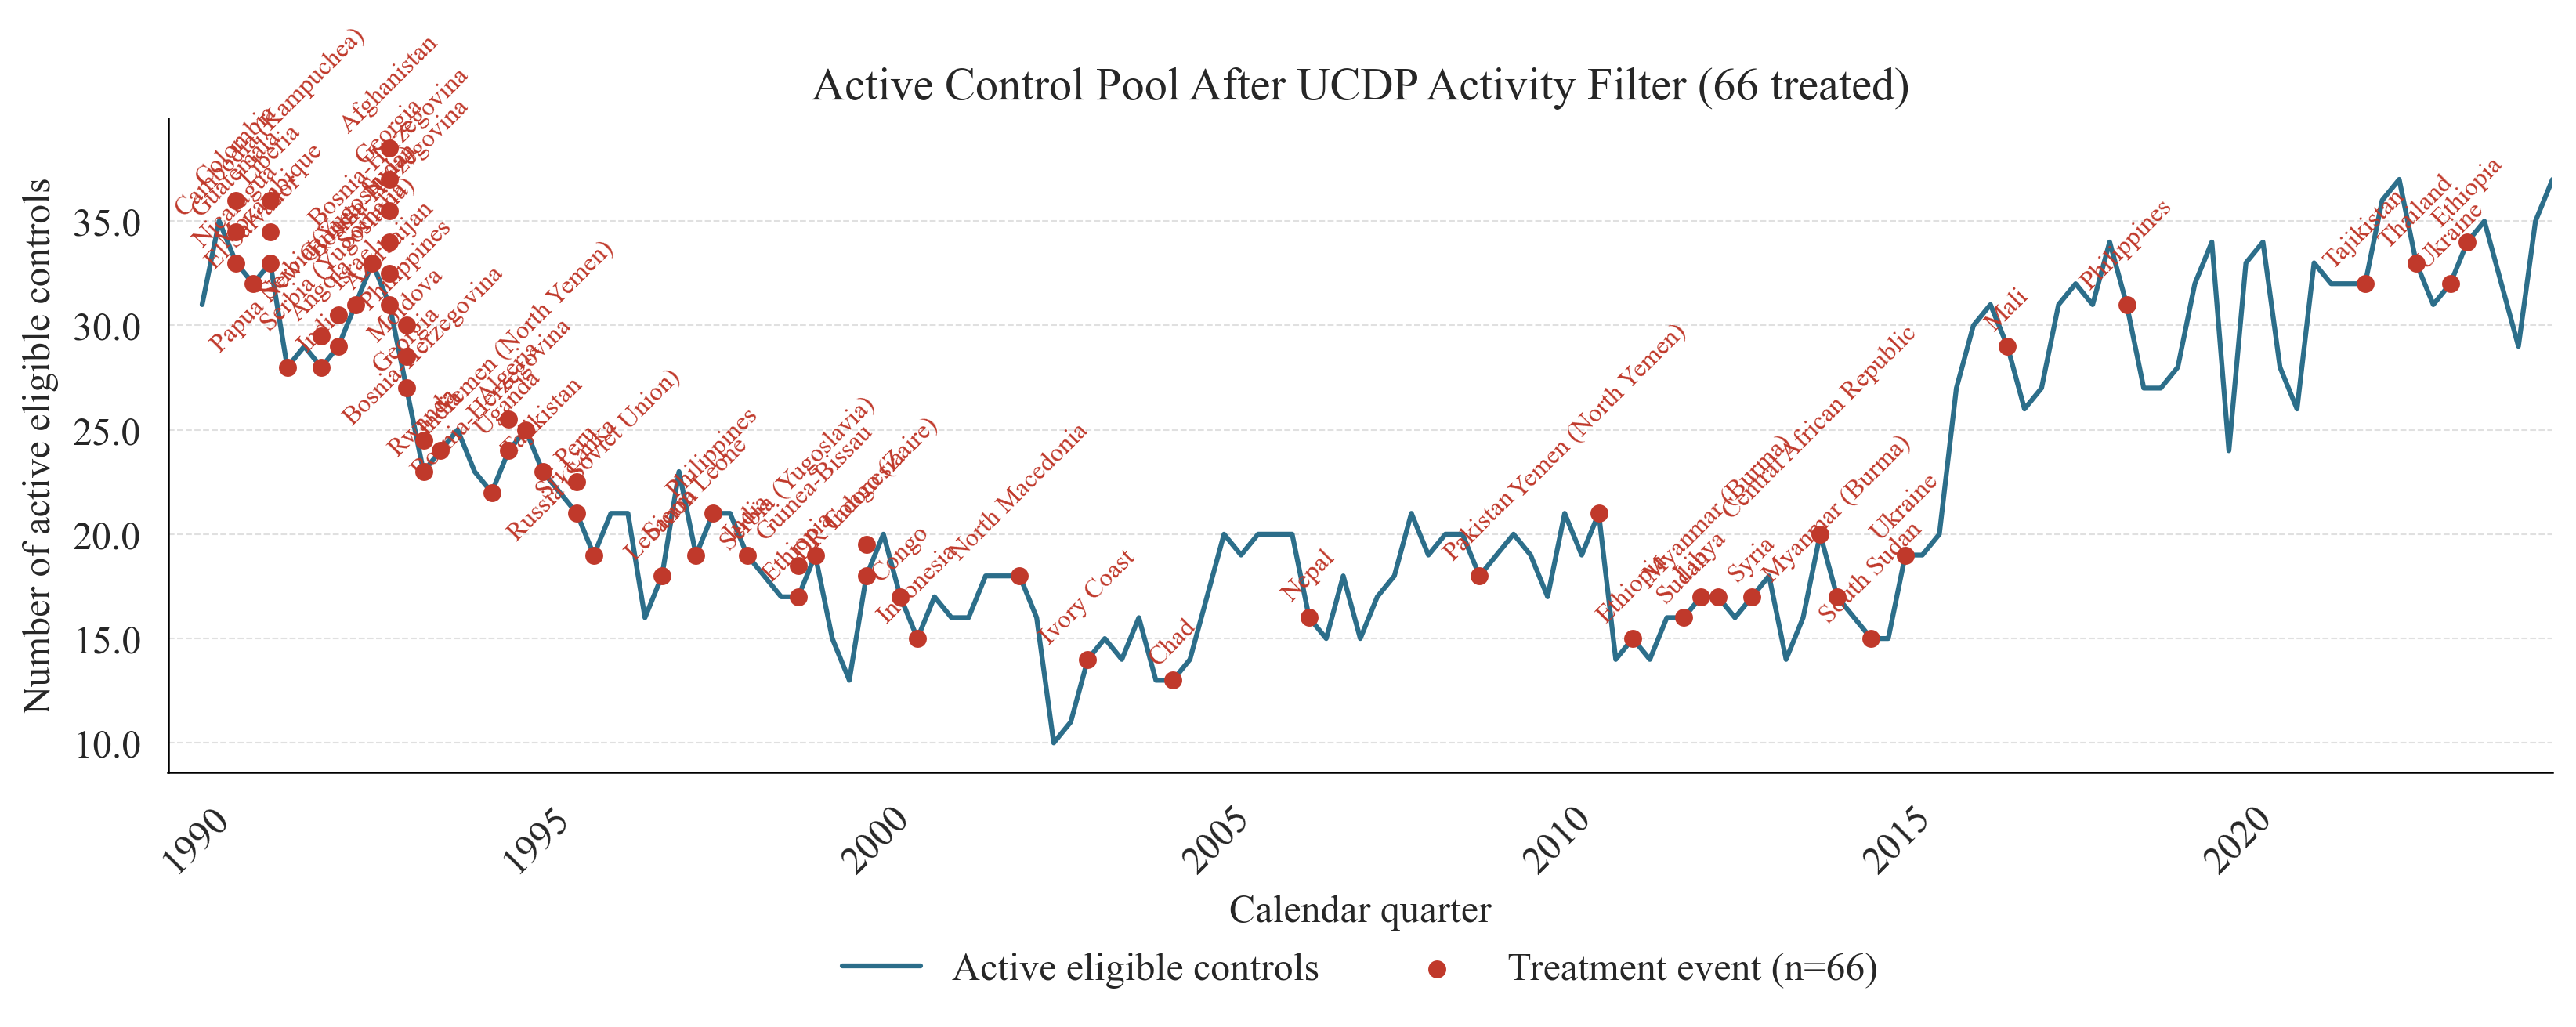

Saved: results/descriptives/fig3_control_pool_post.png


In [14]:
# ── Eligible control POST filter ─────────────────────────────────────────────
# Mirrors first_agreement_csdid.do Section 6:
#   inactive control-period rows (deaths_prev2q < 12 or NaN) are dropped.
#   Remaining gvar==0 rows and not-yet-treated rows are all eligible.
# In Python we keep the full df_q and apply the same conditions explicitly.

# After reclassification, gvar==0 ↔ first_agreement_quarter_f is NaN
# (covers never-treated AND reclassified low-activity treated conflicts)
df_q['elig_post'] = (
    (df_q['start_yq'] <= df_q['yq_int']) &
    (df_q['yq_int']   <= df_q['end_yq']) &
    (
        df_q['first_agreement_quarter_f'].isna() |
        (df_q['yq_int'] < df_q['first_agreement_quarter_f'])
    ) &
    (df_q['deaths_prev2q'] >= THRESHOLD)   # mirrors the Stata inactive-row drop
).astype(int)

n_ctrl_post = df_q.groupby('yq_int')['elig_post'].sum()

# In Stata, inactive rows are physically dropped so quarters with 0 eligible
# controls don't appear in the dataset at all — the plotted line starts from
# the first quarter with surviving rows.  Mirror that here.
n_ctrl_post_plot = n_ctrl_post[n_ctrl_post > 0]

# Treatment events after filter (66 red dots)
treat_post = df_q[df_q['first_agreement_f'] == 1][['yq_int', 'country']].copy()
treat_post['y_base'] = treat_post['yq_int'].map(lambda q: n_ctrl_post.get(q, 0))
treat_post['x']      = yq_to_float(treat_post['yq_int'].values)
treat_post = treat_post.sort_values('yq_int').reset_index(drop=True)
treat_post['rank_q'] = treat_post.groupby('yq_int').cumcount()
treat_post['y_dot']  = treat_post['y_base'] + treat_post['rank_q'] * 1.5

print(f'Treatment events after filter: {len(treat_post)}')
print(f'First quarter with eligible controls: yq_int={n_ctrl_post_plot.index[0]}',
      f'= {yq_to_label(n_ctrl_post_plot.index[0])}',
      f'  n={n_ctrl_post_plot.iloc[0]}')

x_line = yq_to_float(n_ctrl_post_plot.index.values)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(x_line, n_ctrl_post_plot.values, color=C_NOAGR, lw=1.5, label='Active eligible controls')
ax.scatter(treat_post['x'], treat_post['y_dot'],
           color=C_AGR, s=22, zorder=5, label=f'Treatment event (n={len(treat_post)})')
for _, row in treat_post.iterrows():
    ax.annotate(
        row['country'], (row['x'], row['y_dot']),
        textcoords="offset points", xytext=(0, 5),
        ha='center', fontsize=8, color=C_AGR, rotation=45
    )

ax.set_xlabel('Calendar quarter', fontsize=12)
ax.set_ylabel('Number of active eligible controls', fontsize=12)
ax.set_title(
    f'Active Control Pool After UCDP Activity Filter ({len(treat_post)} treated)',
    fontsize=14
)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22),
          frameon=False, fontsize=12, ncol=2)
ax.set_xlim(1989, 2024)
ticks = list(range(1990, 2025, 5))
ax.set_xticks(ticks)
ax.set_xticklabels([str(y) for y in ticks], rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(ax.get_yticks(), fontsize=12)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.grid(False, axis='x')
plt.tight_layout()
plt.savefig(OUTDIR / 'fig3_control_pool_post.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', OUTDIR / 'fig3_control_pool_post.png')

## Figure 4 — Pre-treatment violence: treated vs controls (side by side)

In [15]:
def pretreat_violence_by_cohort(df_q, use_filter=False):
    """
    For each treatment quarter, compute:
      mean_t = mean(deaths_prev2q) across treated conflicts at that quarter
      mean_c = mean(deaths_prev2q) across eligible controls at that quarter

    Left panel  (use_filter=False): uses avg_deaths = deaths_prev2q / 2 (Stata Section 11b)
    Right panel (use_filter=True) : uses deaths_prev2q as-is  (Stata Section 16b)
    """
    faq_col = 'first_agreement_quarter_f' if use_filter else 'first_agreement_quarter'
    fa_col  = 'first_agreement_f'          if use_filter else 'first_agreement'
    divisor = 1 if use_filter else 2   # left panel divides by 2

    treat_rows = df_q[df_q[fa_col] == 1].copy()

    records = []
    for yq_t, grp in treat_rows.groupby('yq_int'):
        mean_t = grp['deaths_prev2q'].mean() / divisor

        # Eligible controls at this quarter
        ctrl_alive  = (df_q['start_yq'] <= yq_t) & (yq_t <= df_q['end_yq'])
        ctrl_untrt  = df_q[faq_col].isna() | (yq_t < df_q[faq_col])
        ctrl_active = (df_q['deaths_prev2q'] >= THRESHOLD) if use_filter else True
        ctrl_mask   = (df_q['yq_int'] == yq_t) & ctrl_alive & ctrl_untrt & ctrl_active
        mean_c = df_q.loc[ctrl_mask, 'deaths_prev2q'].mean() / divisor

        records.append({
            'yq_int':   yq_t,
            'x':        yq_to_float(yq_t),
            'ln_mean_t': np.log(mean_t + 1) if pd.notna(mean_t) and mean_t >= 0 else np.nan,
            'ln_mean_c': np.log(mean_c + 1) if pd.notna(mean_c) and mean_c >= 0 else np.nan,
        })

    return pd.DataFrame(records).sort_values('yq_int')

result_raw = pretreat_violence_by_cohort(df_q, use_filter=False)
result_flt = pretreat_violence_by_cohort(df_q, use_filter=True)
print('Raw panel cohort-quarters:', len(result_raw))
print('Filtered panel cohort-quarters:', len(result_flt))

Raw panel cohort-quarters: 49
Filtered panel cohort-quarters: 48


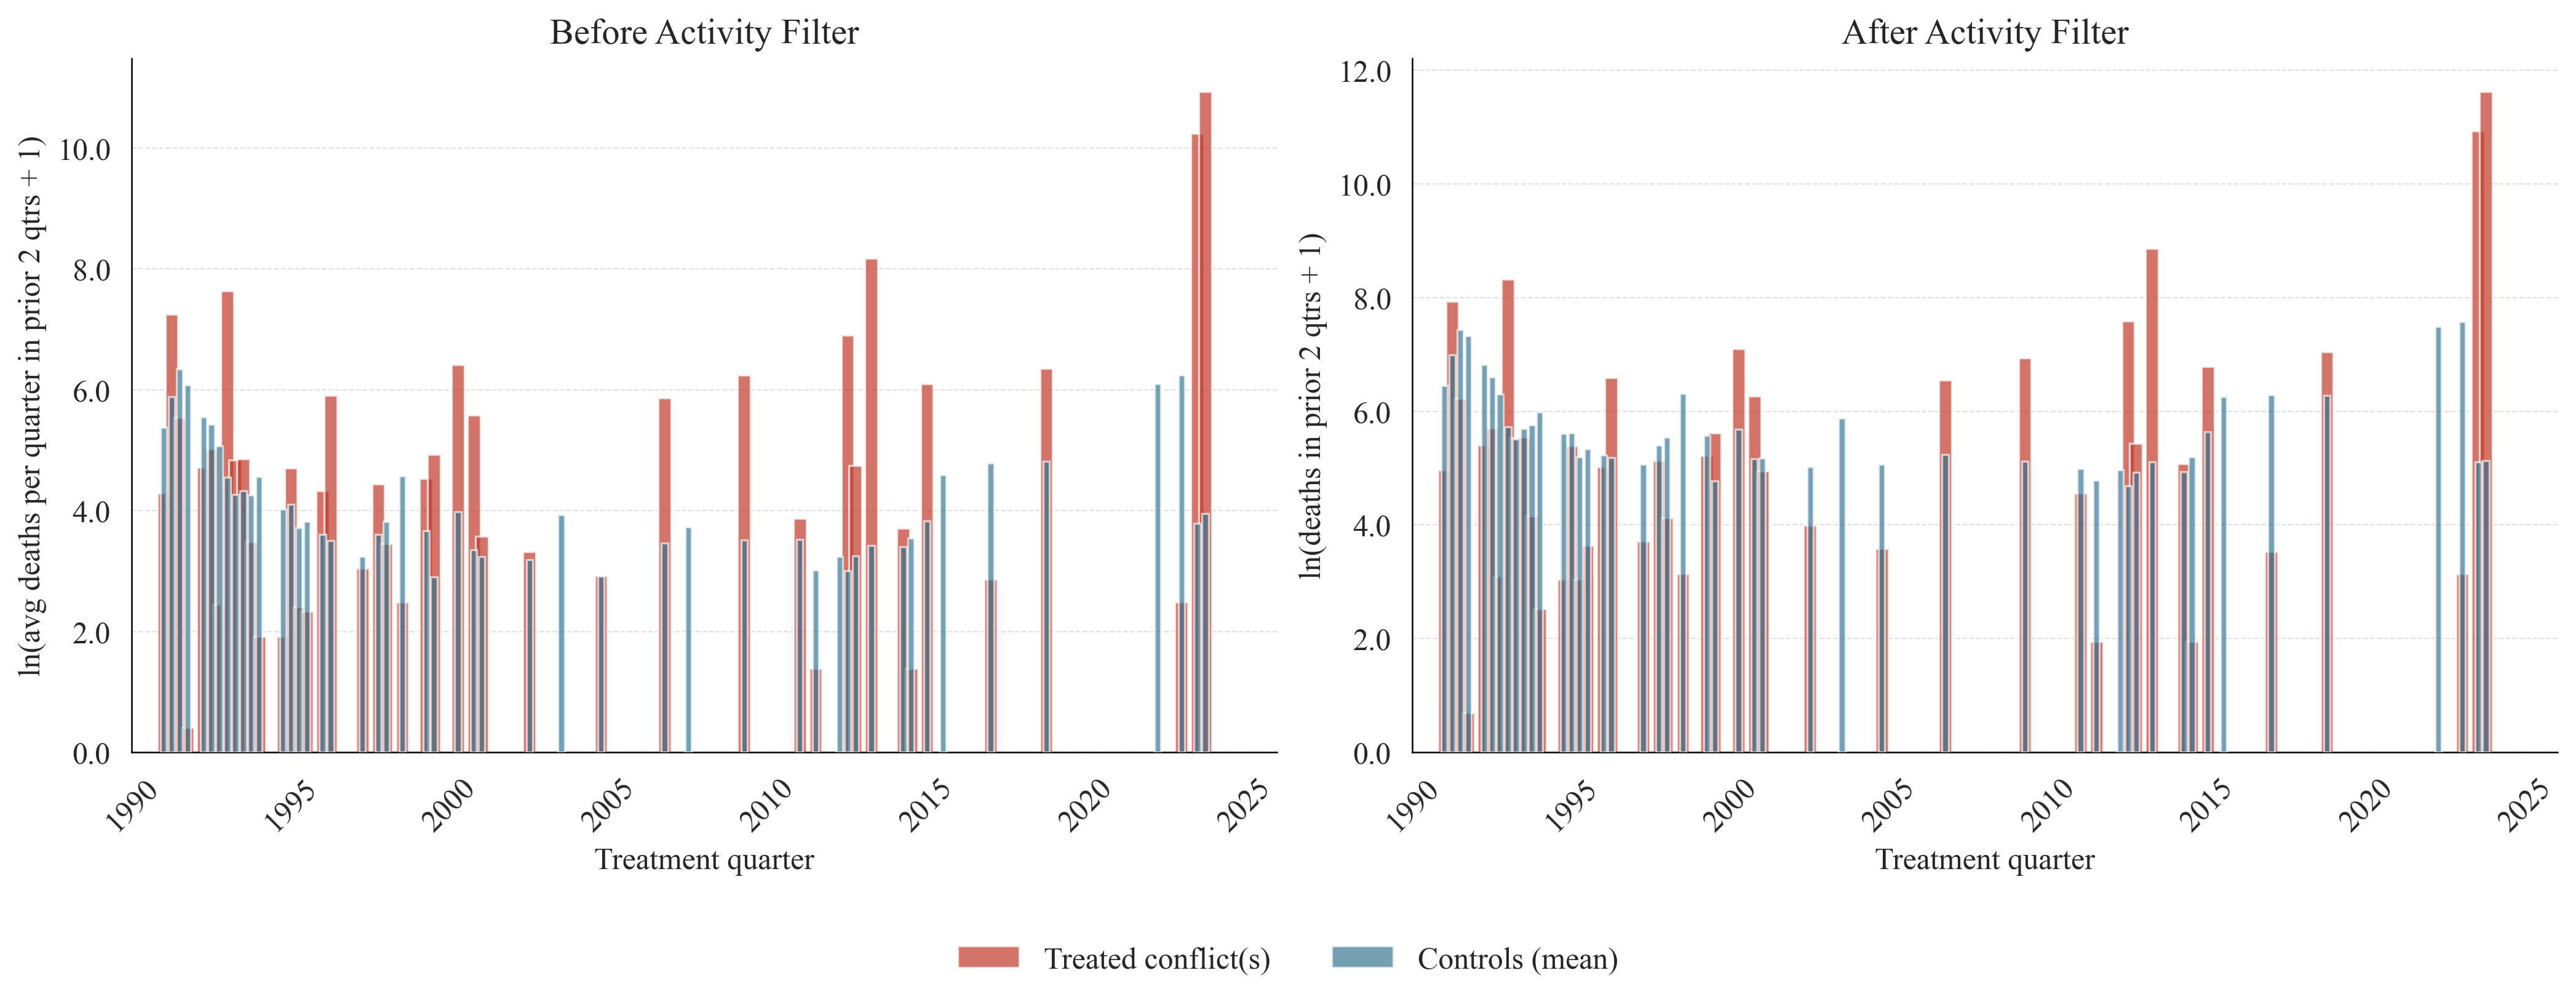

Saved: results/descriptives/fig4_pretreat_violence.png


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, result, title, ylabel in [
    (ax1, result_raw, 'Before Activity Filter',
     'ln(avg deaths per quarter in prior 2 qtrs + 1)'),
    (ax2, result_flt, 'After Activity Filter',
     'ln(deaths in prior 2 qtrs + 1)'),
]:
    x   = result['x'].values
    w_t = 0.40   # wide bar for treated  (≈ 2 quarters)
    w_c = 0.20   # narrow bar for controls (≈ 1 quarter)

    ax.bar(x, result['ln_mean_t'].values, width=w_t,
           color=C_AGR, alpha=0.7, label='Treated conflict(s)', zorder=2)
    ax.bar(x, result['ln_mean_c'].values, width=w_c,
           color=C_NOAGR, alpha=0.65, label='Controls (mean)', zorder=3)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Treatment quarter', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlim(1989, 2025)
    ticks = list(range(1990, 2026, 5))
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(y) for y in ticks], rotation=45, ha='right', fontsize=12)
    ax.set_yticklabels(ax.get_yticks(), fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.grid(False, axis='x')

# Shared legend centered below both panels
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0),
           frameon=False, fontsize=12, ncol=2)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig(OUTDIR / 'fig4_pretreat_violence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', OUTDIR / 'fig4_pretreat_violence.png')

## Figure 5 — Violence trajectories: treated vs control over calendar time

In [17]:
def compute_trajectories(df_q, use_filter=False):
    """
    Tag each conflict-quarter as treated or control, then return
    group-average ln(deaths+1) by calendar quarter.

    Treated at yq t: signed first agreement at or before t AND alive at t.
    Control at yq t: alive AND (never-treated OR not-yet-treated).
    Filtered control also requires deaths_prev2q >= THRESHOLD.
    """
    faq_col = 'first_agreement_quarter_f' if use_filter else 'first_agreement_quarter'
    treated_ids = active_ids if use_filter else set(first_agree_info.index)

    alive = (df_q['start_yq'] <= df_q['yq_int']) & (df_q['yq_int'] <= df_q['end_yq'])

    df_q['_is_treated'] = (
        alive &
        df_q['conflict_id'].isin(treated_ids) &
        df_q[faq_col].notna() &
        (df_q['yq_int'] >= df_q[faq_col])
    )

    ctrl_base = alive & (
        df_q[faq_col].isna() | (df_q['yq_int'] < df_q[faq_col])
    )
    if use_filter:
        ctrl_base = ctrl_base & (df_q['deaths_prev2q'] >= THRESHOLD)
    df_q['_is_control'] = ctrl_base

    treated_avg = (
        df_q[df_q['_is_treated']]
        .groupby('yq_int')['ln_deaths']
        .mean()
    )
    control_avg = (
        df_q[df_q['_is_control']]
        .groupby('yq_int')['ln_deaths']
        .mean()
    )

    df_q.drop(columns=['_is_treated', '_is_control'], inplace=True, errors='ignore')
    return treated_avg, control_avg

trt_raw,  ctrl_raw  = compute_trajectories(df_q, use_filter=False)
trt_flt,  ctrl_flt  = compute_trajectories(df_q, use_filter=True)

print('Treated obs (raw):', trt_raw.shape,  '  Control obs (raw):', ctrl_raw.shape)
print('Treated obs (flt):', trt_flt.shape,  '  Control obs (flt):', ctrl_flt.shape)

Treated obs (raw): (140,)   Control obs (raw): (144,)
Treated obs (flt): (140,)   Control obs (flt): (142,)


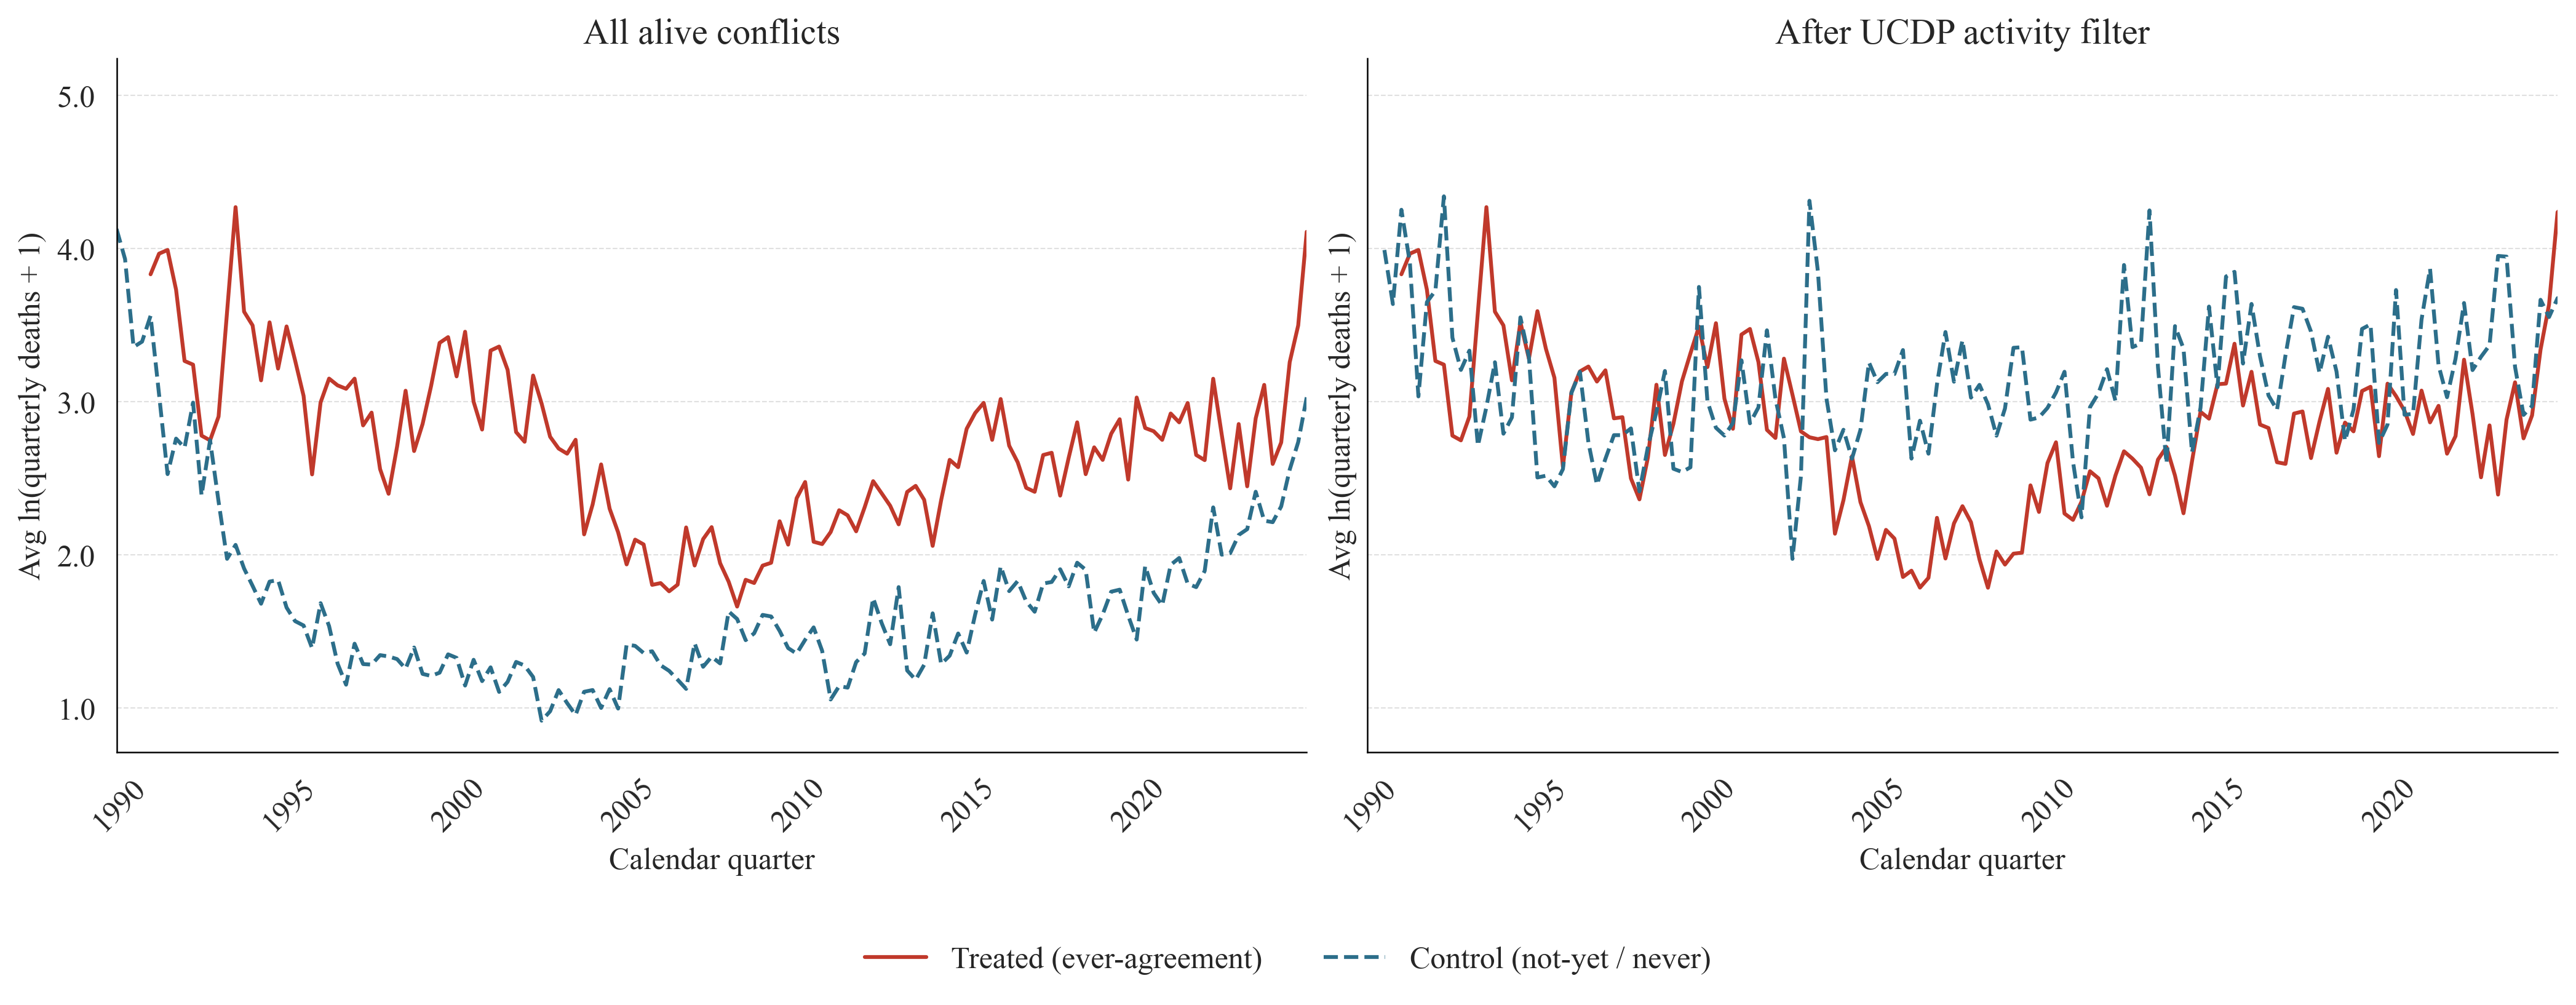

Saved: results/descriptives/fig5_trajectories.png


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (trt, ctrl), title in [
    (ax1, (trt_raw, ctrl_raw), 'All alive conflicts'),
    (ax2, (trt_flt, ctrl_flt), 'After UCDP activity filter'),
]:
    x_t = yq_to_float(trt.index.values)
    x_c = yq_to_float(ctrl.index.values)

    ax.plot(x_t, trt.values,  color=C_AGR,   lw=1.5, label='Treated (ever-agreement)')
    ax.plot(x_c, ctrl.values, color=C_NOAGR, lw=1.5, label='Control (not-yet / never)',
            linestyle='--')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Calendar quarter', fontsize=12)
    ax.set_ylabel('Avg ln(quarterly deaths + 1)', fontsize=12)
    ax.set_xlim(1989, 2024)
    ticks = list(range(1990, 2025, 5))
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(y) for y in ticks], rotation=45, ha='right', fontsize=12)
    ax.set_yticklabels(ax.get_yticks(), fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.grid(False, axis='x')

# Shared legend centered below both panels
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0),
           frameon=True, fontsize=12, ncol=2)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig(OUTDIR / 'fig5_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', OUTDIR / 'fig5_trajectories.png')

## Summary

| Figure | File | Description |
|--------|------|-------------|
| 1 | `fig1_control_pool_pre.png` | Control pool over time, before filter (71 treated, `agreement_ged`) |
| 2 | `fig2_individual_violence.png` | Horizontal bar chart of quarterly window deaths |
| 3 | `fig3_control_pool_post.png` | Active control pool after filter (66 treated) |
| 4 | `fig4_pretreat_violence.png` | Pre-treatment violence — raw vs filtered (side by side) |
| 5 | `fig5_trajectories.png` | Violence trajectories treated vs control — raw vs filtered |

## 6. Descriptive Tables

Produces Tables 1–6 from the paper and saves each to `results/tables/`.

- **Table 1** — Conflict characteristics by agreement status  
- **Table 2** — Agreement status by region  
- **Table 3** — Logit model: probability of ever having an agreement  
- **Table 4** — Type of first agreement  
- **Table 5** — Violence in quarterly window (2 prior quarters + agreement quarter)  
- **Table 6** — Excluded conflicts: below activity threshold

In [19]:
import statsmodels.api as sm

TABDIR = Path('results/descriptives/tables')
TABDIR.mkdir(parents=True, exist_ok=True)

def write_tex(fname, content):
    p = TABDIR / fname
    p.write_text(content)
    print(f'Saved: {p}')

def _f(x, decimals=1):
    """Format a number; use commas for values >= 1000."""
    if pd.isna(x): return '---'
    if abs(x) >= 1000:
        return f'{x:,.0f}' if decimals == 0 else f'{x:,.{decimals}f}'
    return f'{x:.{decimals}f}'

def pval_str(p):
    if p < 0.001: return r'$<$0.001'
    return f'{p:.3f}'

print('Tables output dir:', (TABDIR).resolve())

Tables output dir: /Users/luciasauer/Library/CloudStorage/GoogleDrive-lucia.sauer@bse.eu/Mi unidad/EconAI/1_agreements_violence/agreements_violence/src/4_csdid/results/descriptives/tables


In [20]:
# ── Conflict-level dataset ────────────────────────────────────────────────────
clvl = df.groupby('conflict_id').agg(
    total_fatalities   = ('best',           'sum'),
    peak_monthly       = ('best',           'max'),
    avg_monthly        = ('best',           'mean'),
    active_months      = ('best',           lambda x: (x > 0).sum()),
    n_agreement_months = ('agreement_ged',  'sum'),   # agreement_ged: only active-violence months
    region             = ('region',         'first'),
    country            = ('country',        'first'),
    isocode            = ('isocode',        'first'),
    duration_months    = ('duration_months','first'),
).reset_index()

clvl['duration_years']  = clvl['duration_months'] / 12
clvl['ever_agreement']  = (clvl['n_agreement_months'] > 0).astype(int)

# ── Multiple conflicts binary ─────────────────────────────────────────────────
# = 1 if this conflict ever co-existed with another active conflict in the same country
_act = df[df['best'] > 0][['conflict_id', 'isocode', 'year_mo_numeric']].copy()
_cmc = _act.groupby(['isocode', 'year_mo_numeric'])['conflict_id'].nunique()
_act = _act.merge(_cmc.rename('nc').reset_index(), on=['isocode', 'year_mo_numeric'])
_multi = (_act.groupby('conflict_id')['nc'].max() > 1).astype(int).rename('multiple_conflicts_binary')
clvl  = clvl.merge(_multi.reset_index(), on='conflict_id', how='left')
clvl['multiple_conflicts_binary'] = clvl['multiple_conflicts_binary'].fillna(0).astype(int)

# ── Agreement type for first agreement ───────────────────────────────────────
# first_agree_flag is derived from agreement_ged, so this correctly identifies
# the first agreement month during active violence.
# Agreement type columns (comp/subs/cea) are used for classification at that month.
_fat = df[df['first_agree_flag'] == 1][
    ['conflict_id', 'comp_agreement', 'subs_agreement', 'cea_agreement']
].copy()
def _classify(row):
    if row['comp_agreement'] == 1: return 'Comprehensive'
    if row['subs_agreement'] == 1: return 'Substantive'
    if row['cea_agreement']  == 1: return 'Ceasefire'
    return 'Other/Process'
_fat['agr_type'] = _fat.apply(_classify, axis=1)
clvl = clvl.merge(_fat[['conflict_id', 'agr_type']], on='conflict_id', how='left')

# ── Best fatalities at the agreement quarter (needed for Tables 5 & 6) ────────
_treat_q = (
    df_q[df_q['first_agreement'] == 1]
    [['conflict_id', 'best', 'deaths_prev2q']]
    .rename(columns={'best': 'best_at_treat_q'})
    .set_index('conflict_id')
)

print(f'N conflicts: {len(clvl)}')
print(f'Ever agreement (agreement_ged): {clvl["ever_agreement"].sum()}')  # expect 71
print(f'Multiple conflicts binary: {clvl["multiple_conflicts_binary"].sum()}')
print('\nAgreement type (first agreement):')
print(clvl[clvl['ever_agreement']==1]['agr_type'].value_counts())
print('\nRegion × agreement status:')
print(clvl.groupby(['region','ever_agreement']).size().unstack(fill_value=0))

N conflicts: 201
Ever agreement (agreement_ged): 71
Multiple conflicts binary: 138

Agreement type (first agreement):
agr_type
Other/Process    26
Ceasefire        25
Substantive      15
Comprehensive     5
Name: count, dtype: int64

Region × agreement status:
ever_agreement   0   1
region                
Africa          54  25
Americas         8   5
Asia            35  19
Europe          12  17
Middle East     21   5


In [21]:
# ── Table 1: Conflict characteristics by agreement status ────────────────────
no_agr  = clvl[clvl['ever_agreement'] == 0]
has_agr = clvl[clvl['ever_agreement'] == 1]
n_no, n_has = len(no_agr), len(has_agr)

def stat_row(col, label, d=1):
    """One LaTeX table row: label & mean_no & sd_no & med_no & mean_has & sd_has & med_has"""
    def cells(data):
        return (f'{_f(data[col].mean(), d)} & '
                f'{_f(data[col].std(),  d)} & '
                f'{_f(data[col].median(), d)}')
    return f'{label} & {cells(no_agr)} & {cells(has_agr)} \\\\\n'

# N agreement months: SD=--- for No-Agreement group (always 0)
_has_agr_m = has_agr['n_agreement_months']
agr_months_row = (
    f'N agreement months & 0 & --- & 0 & '
    f'{_f(_has_agr_m.mean(), 1)} & {_f(_has_agr_m.std(), 1)} & '
    f'{int(_has_agr_m.median())} \\\\\n'
)

body = (
    stat_row('total_fatalities',   'Total fatalities',          d=0) +
    stat_row('peak_monthly',       'Peak monthly fatalities',   d=0) +
    stat_row('avg_monthly',        r'Avg.\ monthly fatalities', d=1) +
    stat_row('duration_years',     'Duration (years)',          d=1) +
    stat_row('active_months',      'Active months',             d=0) +
    agr_months_row
)

tex1 = rf"""\begin{{table}}[H]
\centering
\caption{{Conflict Characteristics by Agreement Status}}
\label{{tab:summary}}
\begin{{threeparttable}}
\begin{{tabular}}{{lcccccc}}
\toprule
& \multicolumn{{3}}{{c}}{{\textbf{{No Agreement}} ($N={n_no}$)}} & \multicolumn{{3}}{{c}}{{\textbf{{Has Agreement}} ($N={n_has}$)}} \\
\cmidrule(lr){{2-4}} \cmidrule(lr){{5-7}}
& Mean & SD & Median & Mean & SD & Median \\
\midrule
{body}\bottomrule
\end{{tabular}}
\begin{{tablenotes}}
\small
\item \textit{{Notes:}} Unit of observation is the conflict. ``Active months'' counts months
with at least some recorded activity in the panel. Duration is measured from start date
to end date of the conflict.
\end{{tablenotes}}
\end{{threeparttable}}
\end{{table}}
"""

print(tex1)
write_tex('table1_summary.tex', tex1)

\begin{table}[H]
\centering
\caption{Conflict Characteristics by Agreement Status}
\label{tab:summary}
\begin{threeparttable}
\begin{tabular}{lcccccc}
\toprule
& \multicolumn{3}{c}{\textbf{No Agreement} ($N=130$)} & \multicolumn{3}{c}{\textbf{Has Agreement} ($N=71$)} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7}
& Mean & SD & Median & Mean & SD & Median \\
\midrule
Total fatalities & 3,134 & 9,278 & 349 & 27,686 & 68,053 & 5,537 \\
Peak monthly fatalities & 405 & 1,298 & 104 & 2,768 & 7,863 & 616 \\
Avg.\ monthly fatalities & 7.3 & 21.5 & 0.8 & 64.1 & 157.5 & 12.8 \\
Duration (years) & 11.5 & 12.0 & 7.7 & 19.3 & 13.0 & 18.9 \\
Active months & 53 & 78 & 19 & 122 & 109 & 87 \\
N agreement months & 0 & --- & 0 & 10.5 & 16.5 & 5 \\
\bottomrule
\end{tabular}
\begin{tablenotes}
\small
\item \textit{Notes:} Unit of observation is the conflict. ``Active months'' counts months
with at least some recorded activity in the panel. Duration is measured from start date
to end date of the conflict.
\end{ta

In [22]:
# ── Table 2: Agreement status by region ──────────────────────────────────────
reg_tbl = (
    clvl.groupby(['region', 'ever_agreement'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: 'no_agr', 1: 'has_agr'})
)
reg_tbl['total']   = reg_tbl['no_agr'] + reg_tbl['has_agr']
reg_tbl['pct_agr'] = reg_tbl['has_agr'] / reg_tbl['total'] * 100

REGION_ORDER = ['Africa', 'Americas', 'Asia', 'Europe', 'Middle East']
reg_tbl = reg_tbl.reindex(REGION_ORDER)

rows = ''
for region, row in reg_tbl.iterrows():
    rows += f'{region} & {int(row.no_agr)} & {int(row.has_agr)} & {row.pct_agr:.1f}\\% \\\\\n'

totals = reg_tbl[['no_agr','has_agr','total']].sum()
pct_tot = totals['has_agr'] / totals['total'] * 100

tex2 = rf"""\begin{{table}}[H]
\centering
\caption{{Agreement Status by Region}}
\label{{tab:region}}
\begin{{tabular}}{{lccc}}
\toprule
Region & No Agreement & Has Agreement & \% with Agreement \\
\midrule
{rows}\midrule
Total & {int(totals.no_agr)} & {int(totals.has_agr)} & {pct_tot:.1f}\% \\
\bottomrule
\end{{tabular}}
\end{{table}}
"""

print(tex2)
write_tex('table2_region.tex', tex2)

\begin{table}[H]
\centering
\caption{Agreement Status by Region}
\label{tab:region}
\begin{tabular}{lccc}
\toprule
Region & No Agreement & Has Agreement & \% with Agreement \\
\midrule
Africa & 54 & 25 & 31.6\% \\
Americas & 8 & 5 & 38.5\% \\
Asia & 35 & 19 & 35.2\% \\
Europe & 12 & 17 & 58.6\% \\
Middle East & 21 & 5 & 19.2\% \\
\midrule
Total & 130 & 71 & 35.3\% \\
\bottomrule
\end{tabular}
\end{table}

Saved: results/descriptives/tables/table2_region.tex


In [23]:
# ── Table 3: Logit — probability of ever having an agreement ─────────────────
logit_data = clvl[['ever_agreement', 'total_fatalities', 'duration_years',
                    'peak_monthly', 'region', 'multiple_conflicts_binary']].dropna().copy()

# Region dummies (Africa = reference, dropped); cast to int to avoid boolean dtype
logit_data = pd.get_dummies(logit_data, columns=['region'], drop_first=False, dtype=int)
# Rename "Middle East" column (space causes issues with some tools)
logit_data = logit_data.rename(columns={'region_Middle East': 'region_MiddleEast'})
for col in ['region_Americas', 'region_Asia', 'region_Europe', 'region_MiddleEast']:
    if col not in logit_data.columns:
        logit_data[col] = 0

X_cols = ['total_fatalities', 'duration_years', 'peak_monthly',
          'region_Americas', 'region_Asia', 'region_Europe',
          'region_MiddleEast', 'multiple_conflicts_binary']

X = sm.add_constant(logit_data[X_cols].astype(float))
y = logit_data['ever_agreement'].astype(float)

logit_res = sm.Logit(y, X).fit(disp=False)
print(logit_res.summary())

# Odds ratios and delta-method SEs: SE(OR) = OR * SE(coef)
OR    = np.exp(logit_res.params)
SE_OR = OR * logit_res.bse
z     = logit_res.tvalues
pval  = logit_res.pvalues

ll   = logit_res.llf
ll0  = logit_res.llnull
pr2  = 1 - ll / ll0
lr   = logit_res.llr
lr_p = logit_res.llr_pvalue
n    = int(logit_res.nobs)

# Labels and display order
LOGIT_LABELS = {
    'const':                   'Constant',
    'total_fatalities':        'Total fatalities',
    'duration_years':          'Duration (years)',
    'peak_monthly':            'Peak monthly fatalities',
    'region_Americas':         r'\quad Americas',
    'region_Asia':             r'\quad Asia',
    'region_Europe':           r'\quad Europe',
    'region_MiddleEast':       r'\quad Middle East',
    'multiple_conflicts_binary': 'Multiple conflicts (in country)',
}
LOGIT_ORDER = [
    'total_fatalities', 'duration_years', 'peak_monthly',
    'region_Americas', 'region_Asia', 'region_Europe', 'region_MiddleEast',
    'multiple_conflicts_binary', 'const',
]

rows_logit = ''
for key in LOGIT_ORDER:
    if key == 'region_Americas':
        rows_logit += r'Region (ref: Africa) & & & & \\' + '\n'
    if key == 'const':
        rows_logit += r'\midrule' + '\n'
    lbl = LOGIT_LABELS[key]
    or_ = f'{OR[key]:.3f}'
    se_ = f'{SE_OR[key]:.3f}'
    z_  = f'{z[key]:.2f}' if z[key] >= 0 else rf'$-${abs(z[key]):.2f}'
    pv_ = pval_str(pval[key])
    rows_logit += f'{lbl} & {or_} & {se_} & {z_} & {pv_} \\\\\n'

lr_p_str = r'$<$0.001' if lr_p < 0.001 else f'= {lr_p:.3f}'

tex3 = rf"""\begin{{table}}[H]
\centering
\caption{{Logit Model: Probability of Ever Having an Agreement}}
\label{{tab:logit}}
\begin{{threeparttable}}
\begin{{tabular}}{{lcccc}}
\toprule
& Odds Ratio & Std.\ Err. & $z$ & $p$-value \\
\midrule
{rows_logit}\midrule
\multicolumn{{5}}{{l}}{{$N = {n}$ \quad Log likelihood $= {ll:.2f}$ \quad Pseudo $R^2 = {pr2:.3f}$ \quad LR $\chi^2({len(X_cols)}) = {lr:.2f}$, $p\ {lr_p_str}$}} \\
\bottomrule
\end{{tabular}}
\begin{{tablenotes}}
\small
\item \textit{{Notes:}} Odds ratios reported. An odds ratio below 1 indicates a negative
association with the probability of an agreement; above 1 a positive association.
\end{{tablenotes}}
\end{{threeparttable}}
\end{{table}}
"""

print(tex3)
write_tex('table3_logit.tex', tex3)

                           Logit Regression Results                           
Dep. Variable:         ever_agreement   No. Observations:                  201
Model:                          Logit   Df Residuals:                      192
Method:                           MLE   Df Model:                            8
Date:                Tue, 30 Jun 2026   Pseudo R-squ.:                  0.2500
Time:                        19:23:02   Log-Likelihood:                -97.901
converged:                       True   LL-Null:                       -130.53
Covariance Type:            nonrobust   LLR p-value:                 4.272e-11
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -1.5103      0.412     -3.665      0.000      -2.318      -0.703
total_fatalities           4.528e-05   2.45e-05      1.846      0.065   -2.79e-06    9

In [24]:
# ── Table 4: Type of first agreement ─────────────────────────────────────────
type_counts = (
    clvl[clvl['ever_agreement'] == 1]['agr_type']
    .value_counts()
    .reindex(['Ceasefire', 'Other/Process', 'Substantive', 'Comprehensive'], fill_value=0)
)
n_typed = type_counts.sum()

rows4 = ''
for typ, cnt in type_counts.items():
    rows4 += f'{typ} & {cnt} & {cnt/n_typed*100:.1f}\\% \\\\\n'

tex4 = rf"""\begin{{table}}[H]
\centering
\caption{{Type of First Agreement}}
\label{{tab:firsttype}}
\begin{{tabular}}{{lcc}}
\toprule
First Agreement Type & Count & Percent \\
\midrule
{rows4}\midrule
Total & {n_typed} & 100\% \\
\bottomrule
\end{{tabular}}
\end{{table}}
"""

print(tex4)
write_tex('table4_firsttype.tex', tex4)

\begin{table}[H]
\centering
\caption{Type of First Agreement}
\label{tab:firsttype}
\begin{tabular}{lcc}
\toprule
First Agreement Type & Count & Percent \\
\midrule
Ceasefire & 25 & 35.2\% \\
Other/Process & 26 & 36.6\% \\
Substantive & 15 & 21.1\% \\
Comprehensive & 5 & 7.0\% \\
\midrule
Total & 71 & 100\% \\
\bottomrule
\end{tabular}
\end{table}

Saved: results/descriptives/tables/table4_firsttype.tex


In [25]:
# ── Table 5: Violence in the quarterly window around first agreement ───────────
# window_deaths_q = deaths_prev2q + best_at_treat_quarter  (already in first_agree_info)

win = first_agree_info[['window_deaths_q', 'active']].copy()
win_all      = win
win_active   = win[win['active']]
win_inactive = win[~win['active']]

n_all, n_act, n_inact = len(win_all), len(win_active), len(win_inactive)

def win_stats(data):
    w = data['window_deaths_q']
    return f'{_f(w.mean(),0)} & {_f(w.median(),0)} & {_f(w.std(),0)}'

def bucket_row(label, lo, hi):
    def cnt(data):
        w = data['window_deaths_q']
        mask = (w >= lo) & (w <= hi) if hi != np.inf else (w >= lo)
        n = mask.sum()
        return str(n) if n > 0 else '---'
    return f'\\quad {label} & {cnt(win_all)} & {cnt(win_active)} & {cnt(win_inactive)} \\\\\n'

stats_block = (
    r'\multicolumn{4}{l}{\textit{Deaths in quarterly window}} \\' + '\n' +
    f'\\quad Mean   & {win_stats(win_all).split("&")[0].strip()} & '
                    f'{win_stats(win_active).split("&")[0].strip()} & '
                    f'{win_stats(win_inactive).split("&")[0].strip()} \\\\\n' +
    f'\\quad Median & {win_stats(win_all).split("&")[1].strip()} & '
                    f'{win_stats(win_active).split("&")[1].strip()} & '
                    f'{win_stats(win_inactive).split("&")[1].strip()} \\\\\n' +
    f'\\quad SD     & {win_stats(win_all).split("&")[2].strip()} & '
                    f'{win_stats(win_active).split("&")[2].strip()} & '
                    f'{win_stats(win_inactive).split("&")[2].strip()} \\\\\n'
)

dist_block = (
    r'[4pt]' + '\n' +
    r'\multicolumn{4}{l}{\textit{Distribution of deaths in quarterly window}} \\' + '\n' +
    bucket_row('1--11 deaths',    1,   11) +
    bucket_row('12--24 deaths',  12,   24) +
    bucket_row('25--99 deaths',  25,   99) +
    bucket_row('100--499 deaths',100,  499) +
    bucket_row('500--999 deaths',500,  999) +
    bucket_row(r'1{,}000+ deaths', 1000, np.inf)
)

tex5 = rf"""\begin{{table}}[H]
\centering
\caption{{Violence in the Quarterly Window Around the First Agreement}}
\label{{tab:preagr_violence}}
\begin{{threeparttable}}
\begin{{tabular}}{{lccc}}
\toprule
& \textbf{{All}} & \textbf{{Active}} & \textbf{{Inactive}} \\
& ($N = {n_all}$) & ($\geq 12$ deaths, $N = {n_act}$) & ($< 12$ deaths, $N = {n_inact}$) \\
\midrule
{stats_block}{dist_block}\bottomrule
\end{{tabular}}
\begin{{tablenotes}}
\small
\item \textit{{Notes:}} ``Deaths in quarterly window'' is the sum of battle-related
fatalities in the two quarters preceding the first agreement plus the agreement
quarter itself ($\texttt{{deaths\_prev2q}} + \texttt{{best\_at\_treat\_quarter}}$).
``Active'' conflicts meet the threshold of $\geq 12$ deaths; ``inactive'' fall below it.
\end{{tablenotes}}
\end{{threeparttable}}
\end{{table}}
"""

print(tex5)
write_tex('table5_preagr_violence.tex', tex5)

\begin{table}[H]
\centering
\caption{Violence in the Quarterly Window Around the First Agreement}
\label{tab:preagr_violence}
\begin{threeparttable}
\begin{tabular}{lccc}
\toprule
& \textbf{All} & \textbf{Active} & \textbf{Inactive} \\
& ($N = 71$) & ($\geq 12$ deaths, $N = 66$) & ($< 12$ deaths, $N = 5$) \\
\midrule
\multicolumn{4}{l}{\textit{Deaths in quarterly window}} \\
\quad Mean   & 4,139 & 4,453 & 6 \\
\quad Median & 303 & 329 & 7 \\
\quad SD     & 20,763 & 21,514 & 3 \\
[4pt]
\multicolumn{4}{l}{\textit{Distribution of deaths in quarterly window}} \\
\quad 1--11 deaths & 5 & --- & 5 \\
\quad 12--24 deaths & 4 & 4 & --- \\
\quad 25--99 deaths & 14 & 14 & --- \\
\quad 100--499 deaths & 23 & 23 & --- \\
\quad 500--999 deaths & 7 & 7 & --- \\
\quad 1{,}000+ deaths & 18 & 18 & --- \\
\bottomrule
\end{tabular}
\begin{tablenotes}
\small
\item \textit{Notes:} ``Deaths in quarterly window'' is the sum of battle-related
fatalities in the two quarters preceding the first agreement plus th

In [26]:
# ── Table 6: Excluded conflicts ───────────────────────────────────────────────
excl = first_agree_info[~first_agree_info['active']].copy()
excl['country'] = excl.index.map(conflict_labels)

# Agreement quarter label (e.g. "1994Q3")
excl['agree_qtr_label'] = excl['first_agreement_quarter'].apply(yq_to_label)

# Best (fatalities) at the agreement quarter and deaths_prev2q
excl = excl.join(_treat_q[['best_at_treat_q', 'deaths_prev2q']])

# Sort by window_deaths_q descending (most active first, to mirror original)
excl = excl.sort_values('window_deaths_q', ascending=False)

rows6 = ''
for _, row in excl.iterrows():
    win_q = int(row['window_deaths_q']) if pd.notna(row['window_deaths_q']) else '---'
    best_q = int(row['best_at_treat_q']) if pd.notna(row['best_at_treat_q']) else '---'
    rows6 += (
        f"{row['country']} & {row['agree_qtr_label']} & "
        f"{best_q} & {win_q} & EXCLUDE \\\\\n"
    )

tex6 = rf"""\begin{{table}}[H]
\centering
\caption{{Excluded Conflicts: Below Activity Threshold in Quarterly Window}}
\label{{tab:preagr_detail}}
\begin{{threeparttable}}
\footnotesize
\begin{{tabular}}{{llrrr}}
\toprule
Conflict & Agreement & Deaths at & Quarterly & Status \\
         & quarter   & agree.\ qtr & window  &        \\
\midrule
{rows6}\bottomrule
\end{{tabular}}
\begin{{tablenotes}}
\small
\item \textit{{Notes:}} ``Deaths at agree.\ qtr'' is fatalities in the agreement quarter.
``Quarterly window'' is $\texttt{{deaths\_prev2q}} + \texttt{{best\_at\_treat\_quarter}}$
(two prior quarters plus agreement quarter). All conflicts fall below the activity
threshold of 12 deaths and are reclassified as never-treated.
\end{{tablenotes}}
\end{{threeparttable}}
\end{{table}}
"""

print(tex6)
write_tex('table6_excluded.tex', tex6)

\begin{table}[H]
\centering
\caption{Excluded Conflicts: Below Activity Threshold in Quarterly Window}
\label{tab:preagr_detail}
\begin{threeparttable}
\footnotesize
\begin{tabular}{llrrr}
\toprule
Conflict & Agreement & Deaths at & Quarterly & Status \\
         & quarter   & agree.\ qtr & window  &        \\
\midrule
Burundi & 1994Q3 & 9 & 9 & EXCLUDE \\
United Kingdom & 1993Q4 & 5 & 8 & EXCLUDE \\
Mali & 2013Q2 & 7 & 7 & EXCLUDE \\
Spain & 2000Q1 & 3 & 3 & EXCLUDE \\
Angola & 2006Q3 & 3 & 3 & EXCLUDE \\
\bottomrule
\end{tabular}
\begin{tablenotes}
\small
\item \textit{Notes:} ``Deaths at agree.\ qtr'' is fatalities in the agreement quarter.
``Quarterly window'' is $\texttt{deaths\_prev2q} + \texttt{best\_at\_treat\_quarter}$
(two prior quarters plus agreement quarter). All conflicts fall below the activity
threshold of 12 deaths and are reclassified as never-treated.
\end{tablenotes}
\end{threeparttable}
\end{table}

Saved: results/descriptives/tables/table6_excluded.tex
